# Machine Learning - Student Performance
Valeria Zúñiga Mendoza | A01705435

In [1]:
!pip install catboost

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# /content/drive/MyDrive/StudentPerfomance/ai_impact_student_performance_dataset.csv
%cd "/content/drive/MyDrive/StudentPerformance"

/content/drive/MyDrive/StudentPerformance


In [4]:
SEED = 42
np.random.seed(SEED)

**Obtener el dataset**


Cargar el dataset `ai_impact_student_performance_dataset.csv`, compuesto por **8,000 registros** y **26 columnas** relacionadas con desempeño académico, uso de IA, hábitos de estudio y características del estudiante.

In [5]:
df = pd.read_csv("ai_impact_student_performance_dataset.csv")
df

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,5,8.1,19.2,8.3,1.9,1.0,10,49.7,1,Low
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,6,5.7,3.0,5.0,1.3,2.9,5,58.4,1,Medium
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,6,4.5,-18.0,5.0,3.5,0.1,9,69.1,1,Medium
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,8,3.4,-19.1,4.7,5.9,0.4,7,49.2,1,Low


Primero mostrar lo que se tiene antes de limpiar.

In [6]:
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [7]:

df.tail()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,5,8.1,19.2,8.3,1.9,1.0,10,49.7,1,Low
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,6,5.7,3.0,5.0,1.3,2.9,5,58.4,1,Medium
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,6,4.5,-18.0,5.0,3.5,0.1,9,69.1,1,Medium
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,8,3.4,-19.1,4.7,5.9,0.4,7,49.2,1,Low
7999,8000,15,Male,12th,4.6,0,42,NaN,NaN,9,...,6,9.7,-4.9,9.0,2.9,2.1,5,69.7,1,Medium


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

Las columnas:

- ai_tools_used
- ai_usage_purpose

Tienen valores "nulos".

Hay 5 columnas de tipo objeto que son categorías.

- gender
- grade_level
- ai_tools_used
- ai_usage_purpose
- performance_category

Son tipo int pero en realidad también son categóricas:
 - uses_ai
 - passed


Todas las demás 19 columnas son numéricas

-----------------
Estadísticas básicas
- medias
- mínimos
- máximos
- posibles outliers


In [9]:
df.describe(include='all')

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
count,8000.00000,8000.00000,8000,8000,8000.000000,8000.000000,8000.000000,6638,6654,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000
unique,NaN,NaN,3,6,NaN,NaN,NaN,5,5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,Male,1st Year,NaN,NaN,NaN,ChatGPT+Gemini,Exam Prep,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,NaN,3908,1356,NaN,NaN,NaN,1399,1368,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4705
mean,4000.50000,18.96725,NaN,NaN,3.286938,0.641000,88.989875,NaN,NaN,5.515125,...,5.484750,5.516450,10.127325,6.465025,3.010600,2.523387,5.463375,56.811988,0.889250,NaN
std,2309.54541,3.15316,NaN,NaN,1.582171,0.479737,52.184077,NaN,NaN,2.883064,...,2.898546,2.586377,17.479288,1.435670,1.744974,1.436991,2.881917,13.455724,0.313842,NaN
min,1.00000,14.00000,NaN,NaN,0.500000,0.000000,0.000000,NaN,NaN,1.000000,...,1.000000,1.000000,-20.000000,4.000000,0.000000,0.000000,1.000000,12.700000,0.000000,NaN
25%,2000.75000,16.00000,NaN,NaN,1.900000,0.000000,43.000000,NaN,NaN,3.000000,...,3.000000,3.200000,-5.000000,5.200000,1.500000,1.300000,3.000000,47.300000,1.000000,NaN
50%,4000.50000,19.00000,NaN,NaN,3.300000,1.000000,89.000000,NaN,NaN,6.000000,...,5.000000,5.500000,10.150000,6.400000,3.000000,2.500000,5.000000,56.900000,1.000000,NaN
75%,6000.25000,22.00000,NaN,NaN,4.600000,1.000000,134.000000,NaN,NaN,8.000000,...,8.000000,7.800000,25.500000,7.700000,4.500000,3.800000,8.000000,66.200000,1.000000,NaN


Revisar si hay valores nulos.

In [10]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
grade_level,0
study_hours_per_day,0
uses_ai,0
ai_usage_time_minutes,0
ai_tools_used,1362
ai_usage_purpose,1346
ai_dependency_score,0


----------------------------

Las siguientes columans presentan valores nulos:

- ai_tools_used
- ai_usage_purpose

Sin embargo esos valores "nulos" son más bien considerados como "No usa IA" y "No tiene un propósito específico para usar IA" por lo que vamos a agregar nuevas categorías.


In [11]:
# Rellenar valores nulos

df["ai_tools_used"] = df["ai_tools_used"].fillna("Does Not Use AI")
df["ai_usage_purpose"] = df["ai_usage_purpose"].fillna("No Specific Purpose")

# Verificar cambios

df.isnull().sum().sort_values()

,0
student_id,0
age,0
gender,0
grade_level,0
study_hours_per_day,0
uses_ai,0
ai_usage_time_minutes,0
ai_tools_used,0
ai_usage_purpose,0
ai_dependency_score,0


**Limpiar dataset**

- Eliminar `student_id`: No aporta valor predictivo.

- Eliminar **leakage**: No tomé en cuenta las columnas de `passed` y `performance_category` porque son resultados que se saben después de saber la calificación final y dependen directamente de esta.

También se eliminó la columna de `uses_ai` porque no coincidía con las otras columnas.

Ejemplo: La columna `uses_ai` decía 0 pero `ai_tools_used` y `ai_usage_purpose` si tenían información de que sí se usó AI. Además, en la descripción del dataset no explicaba nada sobre su significado real, por lo que se decidió descartarla.

In [12]:
# Selección de las columnas a usar

columnas = [
    'age', 'gender', 'grade_level', 'study_hours_per_day',
    'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
    'ai_dependency_score', 'ai_generated_content_percentage',
    'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
    'assignment_scores_avg', 'attendance_percentage',
    'concept_understanding_score', 'study_consistency_index',
    'improvement_rate', 'sleep_hours', 'social_media_hours',
    'tutoring_hours', 'class_participation_score', 'final_score'
]

df = df[columnas].copy()
df.shape

(8000, 22)

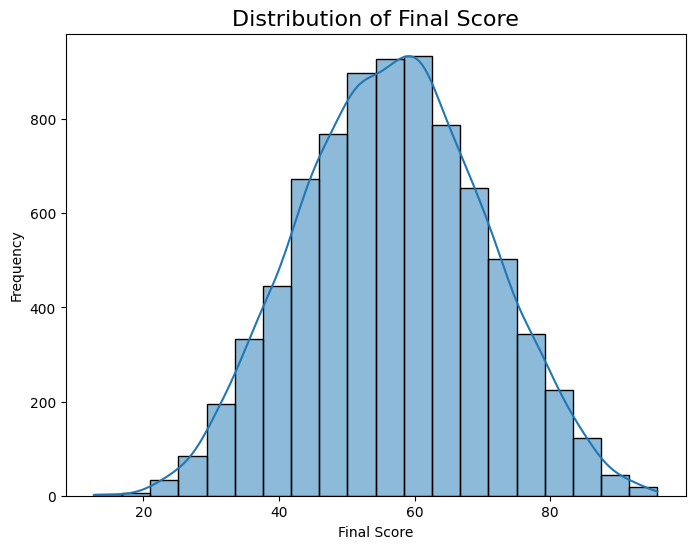

In [13]:

# Crear figura
figure, hist_plot = plt.subplots(figsize=(8,6))

# Histograma
sns.histplot(
    df["final_score"],
    bins=20,
    kde=True,
    ax=hist_plot
)

# Labels
hist_plot.set_xlabel("Final Score")
hist_plot.set_ylabel("Frequency")

# Título
hist_plot.set_title("Distribution of Final Score", fontsize=16)

plt.show()

- Final_score tiene una distribución tipo campana de Gauss.
- La mayoría de estudiantes están concentrados alrededor de: 55 - 65. Y conforme te alejas del centro: hay menos scores muy bajos y muy altos.
- No parece haber desbalance extremo. El target no parece sesgado hacia:
   - puros scores altos
   - puros scores bajos

Lo cual es ideal para regresión.
- No hay outliers enormes visibles

-------------------
**Visualización de features**

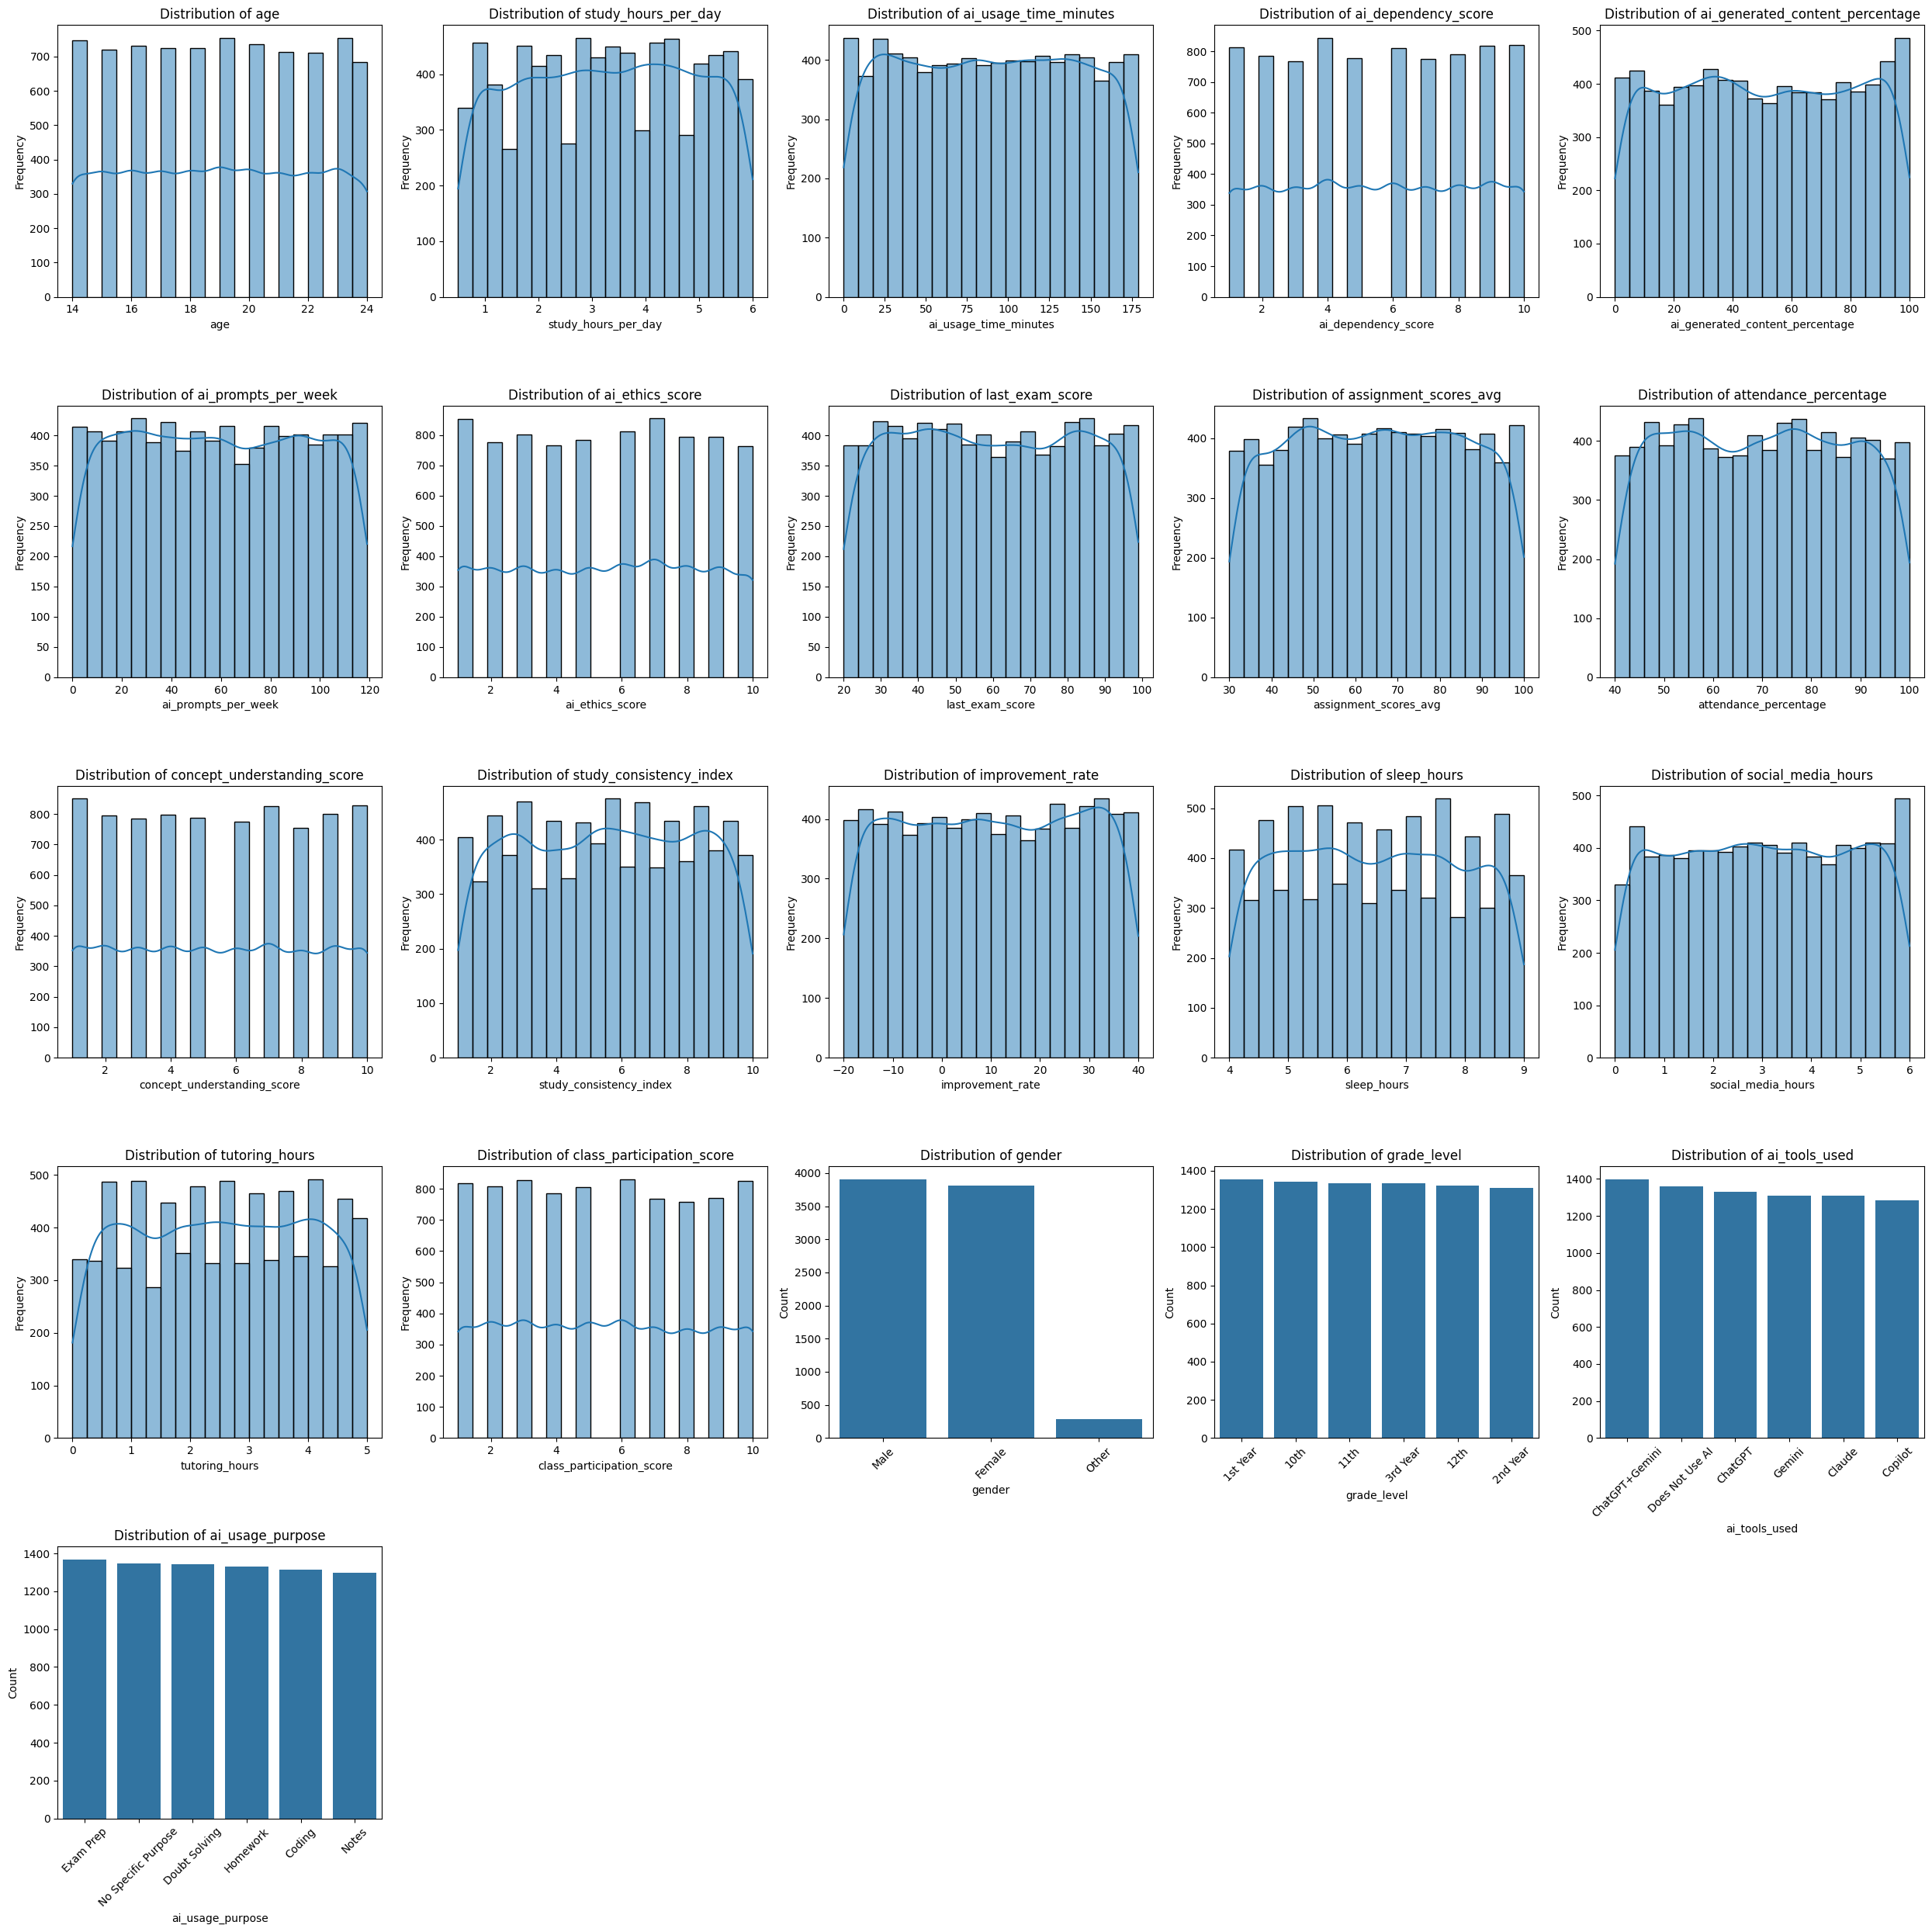

In [14]:
# ====================================
# Features numéricos -> Histogramas

histogram_columns = [
    "age",
    "study_hours_per_day",
    "ai_usage_time_minutes",
    "ai_dependency_score",
    "ai_generated_content_percentage",
    "ai_prompts_per_week",
    "ai_ethics_score",
    "last_exam_score",
    "assignment_scores_avg",
    "attendance_percentage",
    "concept_understanding_score",
    "study_consistency_index",
    "improvement_rate",
    "sleep_hours",
    "social_media_hours",
    "tutoring_hours",
    "class_participation_score"
]

# =====================================
# Features categóricos -> Bar plots

barplot_columns = [
    "gender",
    "grade_level",
    "ai_tools_used",
    "ai_usage_purpose",
]

# =============================================
# Configurar grid para subplots

total_plots = len(histogram_columns) + len(barplot_columns)

# 5 columnas por fila
cols = 5

# calcular filas necesarias
rows = (total_plots // cols) + 1

figure, axes = plt.subplots(rows, cols, figsize=(25, rows * 5))

# convertir axes en lista plana
axes = axes.flatten()

# ==========================================
# Histogramas

for i, column in enumerate(histogram_columns):

    sns.histplot(
        df[column],
        bins=20,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {column}", fontsize=12)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

# ==========================================
# Bar plots

start_index = len(histogram_columns)

for j, column in enumerate(barplot_columns):

    sns.barplot(
        x=df[column].value_counts().index,
        y=df[column].value_counts().values,
        ax=axes[start_index + j]
    )

    axes[start_index + j].set_title(f"Distribution of {column}", fontsize=12)
    axes[start_index + j].set_xlabel(column)
    axes[start_index + j].set_ylabel("Count")

    # rotar labels si son largos
    axes[start_index + j].tick_params(axis='x', rotation=45)

# Eliminar subplots vacíos

for k in range(total_plots, len(axes)):
    figure.delaxes(axes[k])

# Ajustar espacios vacíos y mostrar
plt.tight_layout()
plt.show()

1. Variables categóricas

- Las variables categóricas (grade_level, ai_tools_used, ai_usage_purpose) muestran distribuciones balanceadas.

- La variable "gender" está bastante balanceado entre "male"/"female", "other" tiene menos ejemplos, pero los suficientes para mantenerlo.

2. Variables numéricas
-  En las variables numéricas no se observaron outliers extremos que justificaran eliminar filas. Por esta razón, se conservaron todos los registros.


**Heatmap/correlaciones**

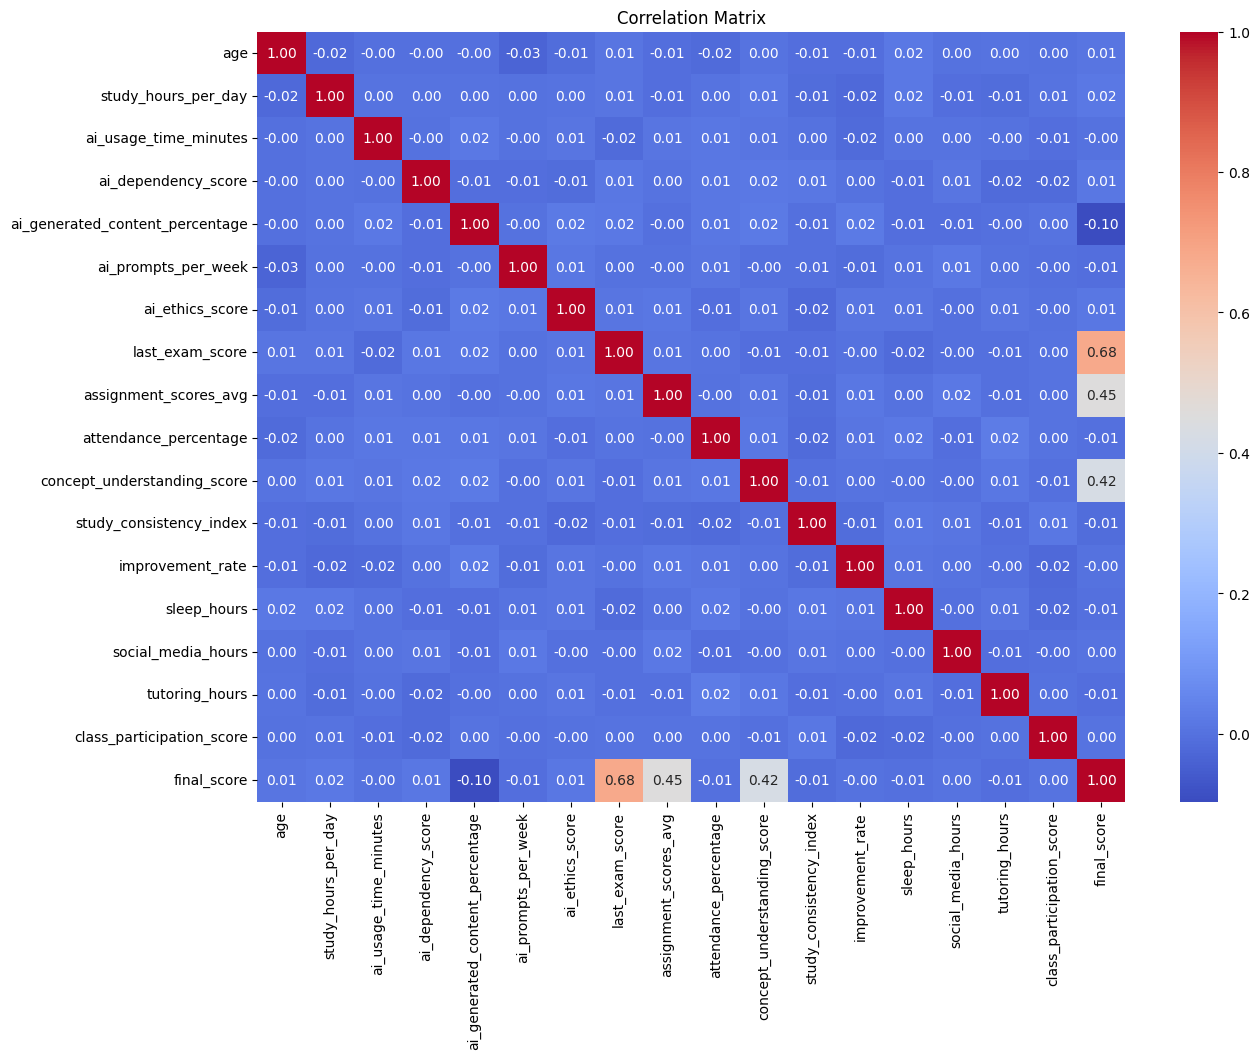

In [15]:
# Calcular correlaciones
corr_matrix = df.corr(numeric_only=True)

# Crear figura
plt.figure(figsize=(14,10))

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Las variables con mayor correlación con final_score son:
- last_exam_score
- assignment_scores_avg
- concept_understanding_score

Ninguna supera 0.7 entonces no son directamente dependientes aunque tengan una fuerte relación, por lo que las mantendremos. Además, si todas las correlaciones fueran bajas entonces el modelo probablemente no aprendería mucho.

>  Para el modelo que se usará "Catboost", se indica que aunque una variable parezca no tener relación individualmente, puede aportar información suplementaria valiosa cuando se combina con otras dentro de modelos complejos.


**Separación del training set, validation set y test set de manera aleatoria**

Primero se separa el dataset en train y test. Después, el conjunto de train se vuelve a dividir en train y validation.  

Se divide el dataset en entrenamiento y prueba antes de entrenar el modelo para evaluar qué tan bien generaliza con datos que no ha visto.

La columna final_score se separa como variable objetivo porque es el valor que queremos predecir.

In [16]:
# Dividir dataset en TRAIN y TEST
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)


# Dividir TRAIN en TRAIN y VALIDATION
train_data, val_data = train_test_split(
    train_data,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print(f"Train shape: {train_data.shape}")
print(f"Validation shape: {val_data.shape}")
print(f"Test shape: {test_data.shape}")

Train shape: (5120, 22)
Validation shape: (1280, 22)
Test shape: (1600, 22)


Como queremos predecir la calificación final y ese dato viene en la columna final_score, debemos quitar esa columna de los fragmentos de datos

In [17]:
# Separar target y features para cada split
train_labels_target = train_data["final_score"]
val_labels_target = val_data["final_score"]
test_labels_target = test_data["final_score"]

train_data = train_data.drop(columns=["final_score"])
val_data = val_data.drop(columns=["final_score"])
test_data = test_data.drop(columns=["final_score"])

In [18]:
display(train_data.head())
display(val_data.head())
display(test_data.head())

,age,gender,grade_level,study_hours_per_day,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
617,16,Male,11th,3.2,117,Copilot,Homework,2,93,89,...,55,38.6,55.8,4,8.6,-12.8,8.1,4.7,1.2,4
2290,18,Female,10th,5.5,117,Gemini,Notes,3,84,62,...,64,88.4,47.9,6,3.4,1.3,7.1,1.7,1.5,8
4289,17,Male,3rd Year,1.6,128,Claude,Homework,8,33,71,...,93,85.0,99.0,5,2.6,14.3,5.9,1.2,2.8,9
1264,20,Male,12th,0.8,103,ChatGPT+Gemini,Doubt Solving,2,19,69,...,61,61.4,56.4,4,1.7,24.3,5.8,3.9,1.9,2
2143,17,Female,10th,4.7,17,Gemini,Doubt Solving,9,20,57,...,48,84.4,93.4,10,8.6,27.3,5.3,1.4,0.7,3


,age,gender,grade_level,study_hours_per_day,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
887,24,Female,12th,4.6,58,Claude,Homework,7,26,87,...,76,67.6,74.9,8,2.7,-1.7,6.6,1.3,5.0,3
3732,17,Female,3rd Year,5.5,95,Gemini,Homework,6,29,43,...,88,44.2,44.0,10,4.1,38.9,5.2,1.6,3.5,9
5326,21,Male,1st Year,5.4,37,Copilot,Homework,10,62,115,...,91,82.3,56.1,7,5.3,18.4,4.0,0.4,4.8,2
667,14,Male,11th,4.8,100,ChatGPT+Gemini,Doubt Solving,8,35,63,...,96,73.4,44.5,4,3.4,22.2,5.7,1.2,1.0,2
1446,22,Female,11th,5.4,47,Gemini,No Specific Purpose,6,83,73,...,93,61.4,85.6,9,7.0,2.9,7.7,2.4,3.2,2


,age,gender,grade_level,study_hours_per_day,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
2215,19,Male,10th,4.6,179,Gemini,Doubt Solving,1,50,79,...,42,43.8,70.1,1,7.0,-8.5,5.7,5.1,4.3,9
2582,14,Female,11th,4.8,127,ChatGPT,Coding,3,55,39,...,92,74.9,95.6,10,9.4,-0.4,5.4,0.8,0.7,2
1662,20,Female,1st Year,2.4,116,Claude,Doubt Solving,10,39,13,...,77,60.5,97.1,6,3.4,-12.1,8.6,2.0,4.9,2
3027,14,Female,1st Year,1.2,123,Does Not Use AI,Doubt Solving,9,54,54,...,71,53.7,53.0,7,8.5,12.5,7.4,5.7,4.5,10
4343,23,Male,11th,3.7,50,Does Not Use AI,Exam Prep,2,35,92,...,85,88.0,95.3,5,6.3,-4.1,6.1,2.7,4.8,10


PREPROCESADO DE FEATURES


Como el modelo, CatBoost, si acepta variables categóricas y numéricas, no hay necesidad de hacer encoding o one hot encoding.


**Feature scaling**

Las variables tienen escalas muy distintas
| Variable            | Rango  |
| ------------------- | ------ |
| sleep_hours         | 0-10   |
| ai_prompts_per_week | 0-1000 |

Normalmente sin scaling, las variables grandes dominarían el entrenamiento.

Para este problema tabular con CatBoost, el escalamiento no es necesario porque el modelo está basado en árboles y divide las variables por umbrales, no por distancias ni gradientes sensibles a magnitudes como ocurre en modelos lineales o redes neuronales.


-----------------------------------
## Construir el modelo

**Modelo seleccionado: CatBoost Regressor**

- `iterations`: número máximo de árboles.
- `learning_rate`: velocidad de aprendizaje.
- `depth`: complejidad de los árboles.
- `loss_function='RMSE'`: función de loss adecuada para regresión.


In [19]:
cat_features = [
    "gender",
    "grade_level",
    "ai_tools_used",
    "ai_usage_purpose"
]

model_catboost = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.003,
    depth=6,
    loss_function="RMSE",
    random_state=SEED,
    verbose=100
)

model_catboost.fit(
    train_data,
    train_labels_target,
    cat_features=cat_features,
    eval_set=(val_data, val_labels_target)
)

pred_train = model_catboost.predict(train_data)
pred_val = model_catboost.predict(val_data)
pred_test = model_catboost.predict(test_data)


0:	learn: 13.4311069	test: 13.1823463	best: 13.1823463 (0)	total: 56.5ms	remaining: 56.5s
100:	learn: 11.0436967	test: 10.8771705	best: 10.8771705 (100)	total: 903ms	remaining: 8.04s
200:	learn: 9.3227715	test: 9.2115539	best: 9.2115539 (200)	total: 1.73s	remaining: 6.9s
300:	learn: 8.0640028	test: 7.9839321	best: 7.9839321 (300)	total: 2.56s	remaining: 5.95s
400:	learn: 7.1632746	test: 7.0999053	best: 7.0999053 (400)	total: 3.36s	remaining: 5.02s
500:	learn: 6.5267367	test: 6.4759745	best: 6.4759745 (500)	total: 4.15s	remaining: 4.13s
600:	learn: 6.0761406	test: 6.0313287	best: 6.0313287 (600)	total: 4.97s	remaining: 3.3s
700:	learn: 5.7622061	test: 5.7234114	best: 5.7234114 (700)	total: 5.79s	remaining: 2.47s
800:	learn: 5.5407012	test: 5.5049573	best: 5.5049573 (800)	total: 7.18s	remaining: 1.78s
900:	learn: 5.3841009	test: 5.3495501	best: 5.3495501 (900)	total: 8.75s	remaining: 961ms
999:	learn: 5.2743212	test: 5.2425103	best: 5.2425103 (999)	total: 10.1s	remaining: 0us

bestTest =

## Métricas de evaluación

Como `final_score` es una variable continua, se usan métricas de regresión. Siguiendo el enfoque reportado por Gul et al. (2025) para predicción de desempeño estudiantil, se consideran métricas de error y ajuste:

- **MAE**: error promedio absoluto en puntos de calificación; es fácil de interpretar.
- **RMSE**: penaliza más los errores grandes, útil para detectar predicciones muy alejadas.
- **R²**: indica qué proporción de la variabilidad de `final_score` logra explicar el modelo.

Estas métricas se calculan en train, validation y test para revisar tanto desempeño como posible sobreajuste.


In [20]:
def get_regression_metrics(y_true, y_pred, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Split": split_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


metrics = pd.DataFrame([
    get_regression_metrics(train_labels_target, pred_train, "Train"),
    get_regression_metrics(val_labels_target, pred_val, "Validation"),
    get_regression_metrics(test_labels_target, pred_test, "Test")
])

display(metrics.round(3))

,Split,MAE,RMSE,R2
0,Train,4.203,5.276,0.846
1,Validation,4.099,5.243,0.842
2,Test,4.186,5.242,0.852


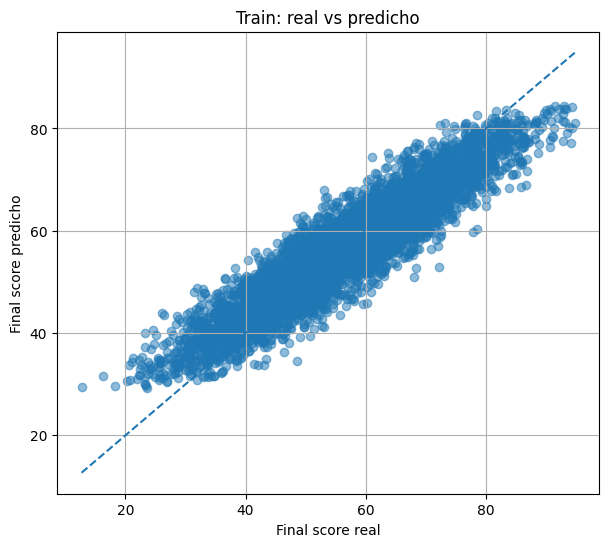

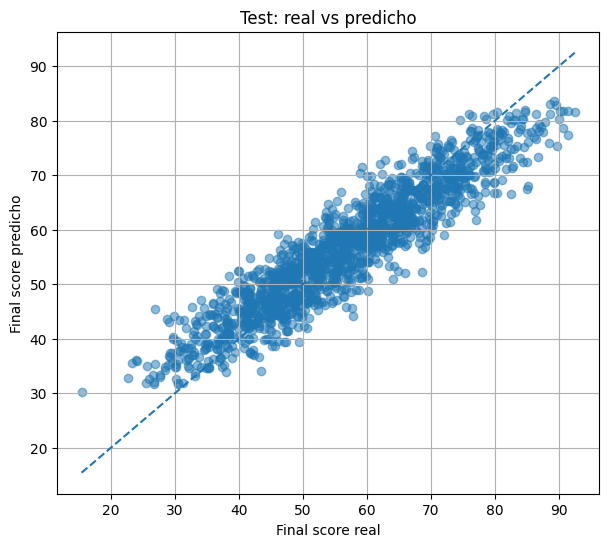

In [21]:

# Gráfica real vs predicho
def plot_real_vs_predicted(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Final score real")
    plt.ylabel("Final score predicho")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_real_vs_predicted(
    train_labels_target,
    pred_train,
    "Train: real vs predicho"
)

plot_real_vs_predicted(
    test_labels_target,
    pred_test,
    "Test: real vs predicho"
)



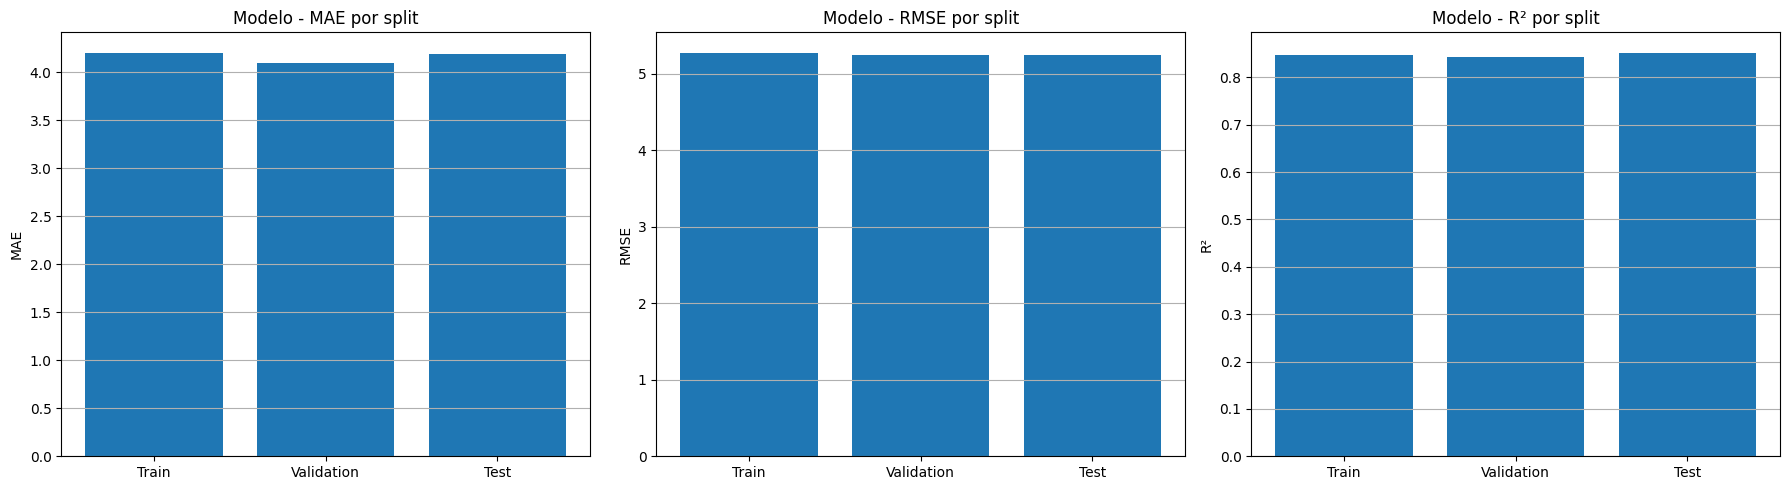

In [22]:
# Comparación de métricas train/ validation / test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(metrics["Split"], metrics["MAE"])
axes[0].set_ylabel("MAE")
axes[0].set_title("Modelo - MAE por split")
axes[0].grid(axis="y")

# RMSE
axes[1].bar(metrics["Split"], metrics["RMSE"])
axes[1].set_ylabel("RMSE")
axes[1].set_title("Modelo - RMSE por split")
axes[1].grid(axis="y")

# R²
axes[2].bar(metrics["Split"], metrics["R2"])
axes[2].set_ylabel("R²")
axes[2].set_title("Modelo - R² por split")
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

## Resultados

El modelo obtuvo resultados muy similares en entrenamiento, validación y prueba.

En el conjunto de prueba, el modelo obtuvo **MAE de 4.186** indica que, en promedio, el modelo se equivoca por aproximadamente 4.2 puntos (más o menos) en la calificación final. El **RMSE de 5.242** muestra que los errores grandes están relativamente controlados. El **R² de 0.852** indica que el modelo explica cerca del 85.2% de la variabilidad del desempeño final en datos no vistos.

Como las métricas de train, validation y test son cercanas, no se observa sobreajuste importante. No hay underfitting ni overfitting. Esto sugiere que CatBoost generaliza adecuadamente para este conjunto de datos.

---------

# Mejora - Modelo 2
CatBoost permite optimizar sus hiperparámetros mediante métodos como **grid_search**. El cual se usa para probar distintas combinaciones de parámetros y seleccionar la que ofrezca el mejor desempeño predictivo.

Este enfoque se respalda en el estudio **Fine Tuned CatBoost and Nature-Inspired Algorithms with Explainable AI**, donde Grid Search fue utilizado como parte del ajuste fino del modelo CatBoost, contribuyendo a mejorar su rendimiento y alcanzar altos niveles de precisión.


> Haque, M. E., Islam, S. M. J., Maliha, J., Sumon, M. S. H., Sharmin, R., & Rokoni, S. (2025). *Improving chronic kidney disease detection efficiency: Fine tuned CatBoost and nature-inspired algorithms with explainable AI.* In 2025 IEEE 14th International Conference on Communication Systems and Network Technologies (CSNT). IEEE. https://doi.org/10.1109/CSNT64827.2025.10968421


**Hiperparámetros**

- `iterations`: número máximo de árboles.
- `learning_rate`: velocidad de aprendizaje.
- `depth`: complejidad de los árboles.
- `l2_leaf_reg`: parámetro de regularización. Evita que el modelo se ajuste demasiado a los datos de entrenamiento.

In [23]:
train_pool = Pool(
    data=train_data,
    label=train_labels_target,
    cat_features=cat_features
)

model_catboost_2 = CatBoostRegressor(
    loss_function="RMSE",
    random_state=SEED,
    verbose=100
)

param_grid = {
    "iterations": [500, 1000, 1500],
    "learning_rate": [0.003, 0.005, 0.01],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [3, 5, 7, 10]
}

grid_result = model_catboost_2.grid_search(
    param_grid,
    X=train_pool,
    cv=3,
    partition_random_seed=SEED,
    verbose=False
)

print("Mejores hiperparámetros:")
print(grid_result["params"])

0:	learn: 57.9683679	test: 58.5780872	best: 58.5780872 (0)	total: 4.76ms	remaining: 2.38s
100:	learn: 43.7450323	test: 44.3107954	best: 44.3107954 (100)	total: 432ms	remaining: 1.71s
200:	learn: 33.2139615	test: 33.7223513	best: 33.7223513 (200)	total: 831ms	remaining: 1.24s
300:	learn: 25.4544238	test: 25.9021608	best: 25.9021608 (300)	total: 1.27s	remaining: 838ms
400:	learn: 19.7013126	test: 20.0881307	best: 20.0881307 (400)	total: 1.67s	remaining: 412ms
499:	learn: 15.5095818	test: 15.8378013	best: 15.8378013 (499)	total: 2.09s	remaining: 0us

bestTest = 15.83780129
bestIteration = 499

0:	learn: 57.8594887	test: 58.4691754	best: 58.4691754 (0)	total: 4.6ms	remaining: 2.29s
100:	learn: 36.3180592	test: 36.8516563	best: 36.8516563 (100)	total: 430ms	remaining: 1.7s
200:	learn: 23.2787508	test: 23.7065195	best: 23.7065195 (200)	total: 853ms	remaining: 1.27s
300:	learn: 15.4151372	test: 15.7409406	best: 15.7409406 (300)	total: 1.28s	remaining: 848ms
400:	learn: 10.7611453	test: 11.015

In [24]:
pred_train_2 = model_catboost_2.predict(train_data)
pred_val_2 = model_catboost_2.predict(val_data)
pred_test_2 = model_catboost_2.predict(test_data)

In [25]:
# Métricas del modelo mejorado
metrics_modelo_2 = pd.DataFrame([
    get_regression_metrics(train_labels_target, pred_train_2, "Train"),
    get_regression_metrics(val_labels_target, pred_val_2, "Validation"),
    get_regression_metrics(test_labels_target, pred_test_2, "Test")
])

metrics_comparison = pd.DataFrame([
    {
        "Modelo": "CatBoost inicial",
        "Split": "Train",
        **get_regression_metrics(train_labels_target, pred_train, "Train")
    },
    {
        "Modelo": "CatBoost mejorado",
        "Split": "Train",
        **get_regression_metrics(train_labels_target, pred_train_2, "Train")
    },
    {
        "Modelo": "CatBoost inicial",
        "Split": "Validation",
        **get_regression_metrics(val_labels_target, pred_val, "Validation")
    },
    {
        "Modelo": "CatBoost mejorado",
        "Split": "Validation",
        **get_regression_metrics(val_labels_target, pred_val_2, "Validation")
    },
    {
        "Modelo": "CatBoost inicial",
        "Split": "Test",
        **get_regression_metrics(test_labels_target, pred_test, "Test")
    },

    {
        "Modelo": "CatBoost mejorado",
        "Split": "Test",
        **get_regression_metrics(test_labels_target, pred_test_2, "Test")
    }
])

metrics_comparison = metrics_comparison[["Modelo", "Split", "MAE", "RMSE", "R2"]]

display(metrics_comparison.round(3))

,Modelo,Split,MAE,RMSE,R2
0,CatBoost inicial,Train,4.203,5.276,0.846
1,CatBoost mejorado,Train,3.868,4.834,0.871
2,CatBoost inicial,Validation,4.099,5.243,0.842
3,CatBoost mejorado,Validation,3.828,4.929,0.860
4,CatBoost inicial,Test,4.186,5.242,0.852
5,CatBoost mejorado,Test,3.910,4.920,0.870


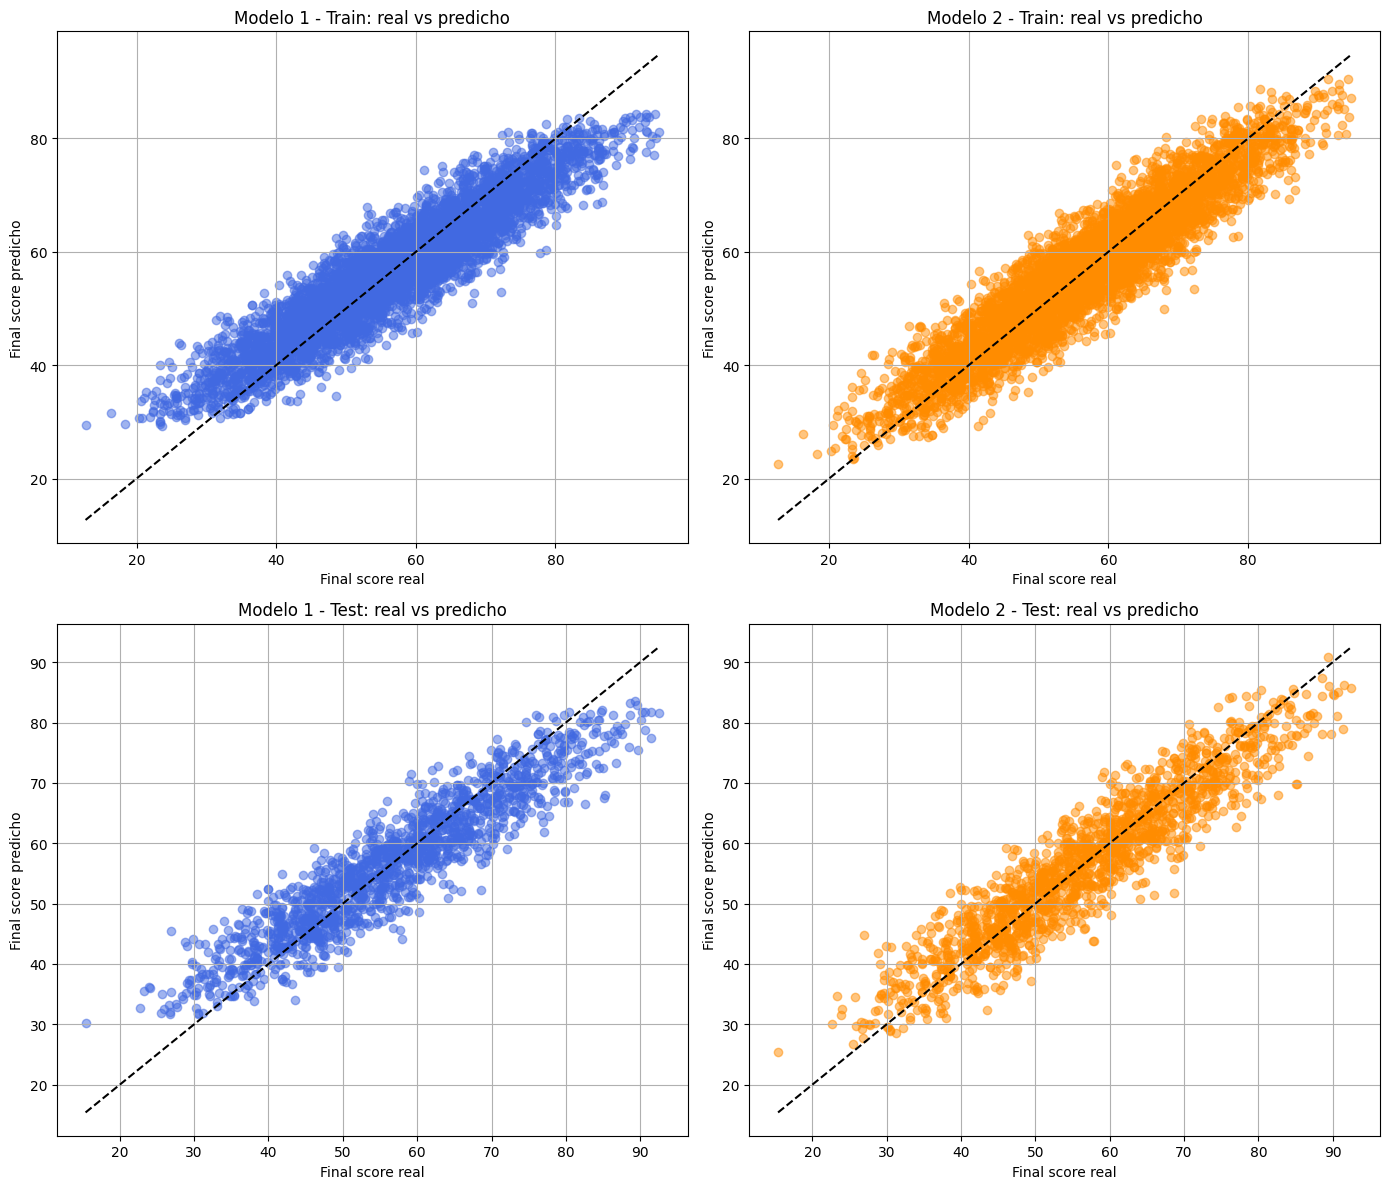

In [26]:
# Gráfica real vs predicho
def plot_real_vs_predicted_ax(ax, y_true, y_pred, title, color):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ax.scatter(y_true, y_pred, alpha=0.5, color=color)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")

    ax.set_xlabel("Final score real")
    ax.set_ylabel("Final score predicho")
    ax.set_title(title)
    ax.grid(True)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Modelo 1
plot_real_vs_predicted_ax(
    axes[0, 0],
    train_labels_target,
    pred_train,
    "Modelo 1 - Train: real vs predicho",
    "royalblue"
)

plot_real_vs_predicted_ax(
    axes[1, 0],
    test_labels_target,
    pred_test,
    "Modelo 1 - Test: real vs predicho",
    "royalblue"
)

# Modelo 2
plot_real_vs_predicted_ax(
    axes[0, 1],
    train_labels_target,
    pred_train_2,
    "Modelo 2 - Train: real vs predicho",
    "darkorange"
)

plot_real_vs_predicted_ax(
    axes[1, 1],
    test_labels_target,
    pred_test_2,
    "Modelo 2 - Test: real vs predicho",
    "darkorange"
)

plt.tight_layout()
plt.show()


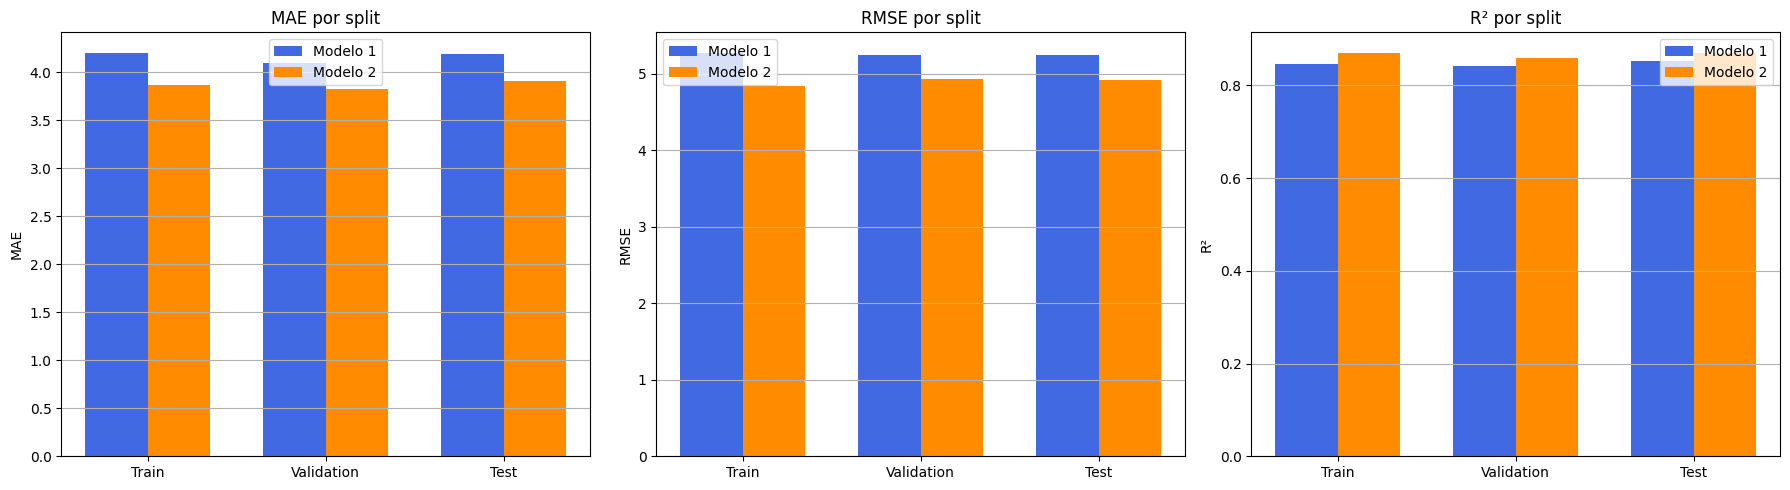

In [27]:
# Comparación de métricas Modelo 1 vs Modelo 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = metrics_modelo_2["Split"]
x = np.arange(len(splits))
width = 0.35

# MAE
axes[0].bar(x - width/2, metrics["MAE"], width, label="Modelo 1", color="royalblue")
axes[0].bar(x + width/2, metrics_modelo_2["MAE"], width, label="Modelo 2", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE por split")
axes[0].legend()
axes[0].grid(axis="y")

# RMSE
axes[1].bar(x - width/2, metrics["RMSE"], width, label="Modelo 1", color="royalblue")
axes[1].bar(x + width/2, metrics_modelo_2["RMSE"], width, label="Modelo 2", color="darkorange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE por split")
axes[1].legend()
axes[1].grid(axis="y")

# R²
axes[2].bar(x - width/2, metrics["R2"], width, label="Modelo 1", color="royalblue")
axes[2].bar(x + width/2, metrics_modelo_2["R2"], width, label="Modelo 2", color="darkorange")
axes[2].set_xticks(x)
axes[2].set_xticklabels(splits)
axes[2].set_ylabel("R²")
axes[2].set_title("R² por split")
axes[2].legend()
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

**Resultados**

El modelo 2, como el modelo 1, obtuvo resultados muy similares en entrenamiento, validación y prueba.

El modelo mejorado muestra valores más bajos de MAE y RMSE lo que quiere decir que las predicciones están más cerca de los valores reales. Mientras que el R2 subió, indicando que los valores son mejor representados por el segundo modelo.

En el conjunto de prueba, el modelo 2 obtuvo **MAE de 3.91**, indicando que, en promedio, el modelo 2 se equivoca por aproximadamente 0.276 puntos menos que el modelo 1. El **RMSE de 4.92**, mostrando que los errores grandes están en promedio 0.322 puntos más controlados que el modelo 1. El **R² de 0.87** indica que el modelo explica cerca del 1.8% mejor que el modelo 1, la variabilidad del desempeño final en datos no vistos.


Las mejoras fueron resultado del ajuste de hiperparámetros mediante **Grid Search**. Sin embargo, las mejoras obtenidas fueron moderadas y no drásticas, lo que sugiere que el modelo inicial ya presentaba un buen desempeño y que el proceso de optimización permitió refinarlo, más que transformar significativamente su capacidad de predicción.


**Guardar modelo**

In [28]:
model_catboost_2.save_model("student_performance_catboost_mejorado.cbm")

------
## Referencia

Gul, M. N., Abbasi, W., Babar, M. Z., Aljohani, A., & Arif, M. (2025). *Data driven decisions in education using a comprehensive machine learning framework for student performance prediction*. Discover Computing, 28, Article 153. https://doi.org/10.1007/s10791-025-09585-3


 Haque, M. E., Islam, S. M. J., Maliha, J., Sumon, M. S. H., Sharmin, R., & Rokoni, S. (2025). *Improving chronic kidney disease detection efficiency: Fine tuned CatBoost and nature-inspired algorithms with explainable AI.* In 2025 IEEE 14th International Conference on Communication Systems and Network Technologies (CSNT). IEEE. https://doi.org/10.1109/CSNT64827.2025.10968421
